
# Phân tích dữ liệu tin đăng cho thuê từ dataset `PhongTro.xlsx`

## Mục tiêu
Bài phân tích này tập trung khám phá mặt bằng giá thuê trong dataset `PhongTro.xlsx`, bao gồm:
- Phân phối giá thuê và diện tích
- Khác biệt theo vị trí
- Khác biệt theo loại hình bất động sản
- Mối quan hệ giữa diện tích và giá thuê
- Phân tích giá trên mét vuông
- Khai thác tín hiệu từ tiêu đề tin đăng
- Tổng hợp insight và nêu rõ hạn chế của dữ liệu

## Phạm vi
- Chỉ sử dụng duy nhất file `PhongTro.xlsx`
- Không sử dụng, không join, không merge với bất kỳ dataset external nào khác

## Lưu ý
Dữ liệu này là dữ liệu **tin đăng**, không phải giá giao dịch thực tế. Vì vậy, các kết luận mang tính mô tả trên mẫu dữ liệu hiện có.

In [1]:
# CÀI ĐẶC CÁC THƯ VIỆN CẦN THIẾT 

from pathlib import Path
import re
import unicodedata
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

# Cấu hình hiển thị
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Style biểu đồ
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [2]:
# CÀI ĐẶT ĐƯỜNG DẪN 

ROOT = Path(r"D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis")
NOTEBOOK_DIR = ROOT / "Analysis_Code" / "notebooks" / "main"
DATA_PATH = ROOT / "Dataset" / "raw" / "Maindataset" / "PhongTro.xlsx"

OUTPUT_DIR = ROOT / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
DATA_OUT_DIR = OUTPUT_DIR / "data"
REPORT_DIR = OUTPUT_DIR / "reports"

for folder in [OUTPUT_DIR, FIG_DIR, DATA_OUT_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Không tìm thấy file dữ liệu: {DATA_PATH}")

print("ROOT:", ROOT)
print("DATA_PATH:", DATA_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)

ROOT: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis
DATA_PATH: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\Dataset\raw\Maindataset\PhongTro.xlsx
OUTPUT_DIR: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\outputs


In [3]:
# HÀM TIỆN ÍCH 

def save_figure(fig, filename: str, dpi: int = 200):
    """Lưu figure vào thư mục output/figures."""
    out_path = FIG_DIR / filename
    fig.tight_layout()
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
    print(f"Đã lưu hình: {out_path}")

def strip_accents(text: str) -> str:
    """Bỏ dấu tiếng Việt."""
    if pd.isna(text):
        return np.nan
    text = str(text)
    text = unicodedata.normalize("NFD", text)
    text = "".join(ch for ch in text if unicodedata.category(ch) != "Mn")
    return unicodedata.normalize("NFC", text)

def normalize_whitespace(text: str) -> str:
    if pd.isna(text):
        return np.nan
    return re.sub(r"\s+", " ", str(text)).strip()

def clean_column_name(col: str) -> str:
    """Đưa tên cột về snake_case không dấu."""
    col = strip_accents(col)
    col = col.lower().strip()
    col = re.sub(r"[^a-z0-9]+", "_", col)
    col = re.sub(r"_+", "_", col).strip("_")
    return col

def extract_number(value):
    """
    Bóc số từ text như:
    '40 m', '25m2', '30 m²', ...
    """
    if pd.isna(value):
        return np.nan
    value = str(value).lower().replace(",", ".")
    match = re.search(r"(\d+(?:\.\d+)?)", value)
    return float(match.group(1)) if match else np.nan

def clean_price(value):
    """
    Làm sạch giá. Với dataset hiện tại giá đã là numeric,
    nhưng hàm này giữ để code an toàn hơn.
    """
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)
    value = str(value).lower().replace(",", "").replace(".", "")
    match = re.search(r"(\d+)", value)
    return float(match.group(1)) if match else np.nan

def normalize_location(text: str) -> str:
    """
    Chuẩn hóa vị trí cho các cách ghi:
    Quận 1 / Quan 1 / phu nhuan / Phú Nhuận ...
    """
    if pd.isna(text):
        return np.nan
    
    raw = normalize_whitespace(text)
    raw_no_accent = strip_accents(raw).lower()

    mapping = {
        "quan 1": "Quận 1",
        "quan 2": "Quận 2",
        "quan 3": "Quận 3",
        "quan 4": "Quận 4",
        "quan 5": "Quận 5",
        "quan 6": "Quận 6",
        "quan 7": "Quận 7",
        "quan 8": "Quận 8",
        "quan 9": "Quận 9",
        "quan 10": "Quận 10",
        "quan 11": "Quận 11",
        "quan 12": "Quận 12",
        "phu nhuan": "Phú Nhuận",
        "tan binh": "Tân Bình",
        "tan phu": "Tân Phú",
        "thu duc": "Thủ Đức",
        "go vap": "Gò Vấp",
        "binh thanh": "Bình Thạnh",
        "binh tan": "Bình Tân",
        "binh chanh": "Bình Chánh",
        "hoc mon": "Hóc Môn",
        "cu chi": "Củ Chi",
        "can gio": "Cần Giờ",
        "nha be": "Nhà Bè",
    }
    return mapping.get(raw_no_accent, raw)

def clean_property_type(text: str) -> str:
    if pd.isna(text):
        return np.nan
    text = normalize_whitespace(text)
    mapping = {
        "PhongTro": "Phòng trọ",
        "NhaNguyenCan": "Nhà nguyên căn",
        "CanHoChungCu": "Căn hộ chung cư",
        "CanHoMini": "Căn hộ mini",
        "Studio": "Studio",
        "CanHo1PN": "Căn hộ 1PN",
        "CanHo2PN": "Căn hộ 2PN",
        "Duplex": "Duplex",
        "Penthouse": "Penthouse",
        "Shophouse": "Shophouse",
    }
    return mapping.get(text, text)

def summarize_numeric(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    """Tạo bảng thống kê mô tả cho biến số."""
    valid_cols = [c for c in cols if c in df.columns]
    if not valid_cols:
        return pd.DataFrame()
    return df[valid_cols].describe().T

def plot_hist_box(df, col, title_prefix, bins=30, x_label=None, filename_prefix=None):
    """Vẽ histogram + boxplot cho một biến số."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.histplot(df[col].dropna(), bins=bins, kde=True, ax=axes[0])
    axes[0].set_title(f"{title_prefix} - Histogram")
    axes[0].set_xlabel(x_label if x_label else col)
    
    sns.boxplot(x=df[col].dropna(), ax=axes[1])
    axes[1].set_title(f"{title_prefix} - Boxplot")
    axes[1].set_xlabel(x_label if x_label else col)
    
    if filename_prefix:
        save_figure(fig, f"{filename_prefix}.png")
    plt.show()

def barplot_counts(series, title, xlabel, ylabel="Số lượng", top_n=None, rotate=45, filename=None):
    counts = series.value_counts(dropna=False)
    if top_n:
        counts = counts.head(top_n)

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(x=counts.index.astype(str), y=counts.values, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=rotate)
    
    if filename:
        save_figure(fig, filename)
    plt.show()

def barplot_median(df, category_col, value_col, title, xlabel, ylabel, min_count=5, rotate=45, filename=None):
    temp = (
        df.groupby(category_col)[value_col]
        .agg(["median", "count"])
        .reset_index()
        .query("count >= @min_count")
        .sort_values("median", ascending=False)
    )
    
    fig, ax = plt.subplots(figsize=(11, 6))
    sns.barplot(data=temp, x=category_col, y="median", ax=ax)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=rotate)
    
    if filename:
        save_figure(fig, filename)
    plt.show()
    
    return temp

def boxplot_by_category(df, category_col, value_col, title, xlabel, ylabel, top_n=None, filename=None):
    temp = df.copy()
    if top_n:
        top_categories = temp[category_col].value_counts().head(top_n).index
        temp = temp[temp[category_col].isin(top_categories)].copy()
    
    order = (
        temp.groupby(category_col)[value_col]
        .median()
        .sort_values(ascending=False)
        .index
    )

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(data=temp, x=category_col, y=value_col, order=order, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=45)
    
    if filename:
        save_figure(fig, filename)
    plt.show()

def make_keyword_flag(text_series, patterns):
    """
    patterns: list regex
    trả về Series bool
    """
    text_norm = (
        text_series.fillna("")
        .astype(str)
        .apply(normalize_whitespace)
        .apply(strip_accents)
        .str.lower()
    )
    regex = "|".join(patterns)
    return text_norm.str.contains(regex, regex=True, na=False)

def print_section(title):
    display(Markdown(f"## {title}"))

In [4]:
# LOAD DỮ LIỆU 

print_section("Load dữ liệu")

df_raw = pd.read_excel(DATA_PATH, sheet_name=0)
print("Shape:", df_raw.shape)
display(df_raw.head())
display(df_raw.info())
print("Columns:", df_raw.columns.tolist())

## Load dữ liệu

Shape: (1399, 6)


,TieuDe,DienTich,GiaVND,ViTri,PhanLoai,SoPhong
0,Studio thang máy Nguyễn Thị Minh Khai gần Thảo...,40 m,8000000,Quận 1,PhongTro,1
1,Khai trương toà nhà mới Ngã 6 Phù Đổng,30 m,8500000,Quận 1,PhongTro,1
2,Phòng ban công giá rẻ gần Lý Chính Thắng,28 m,5500000,Quận 1,PhongTro,1
3,Phòng Studio đẹp khu Hoàng Sa,28 m,8000000,Quận 1,PhongTro,1
4,Phòng ban công rẻ bờ kè Hoàng Sa,25 m,5200000,Quận 1,PhongTro,1


<class 'pandas.DataFrame'>
RangeIndex: 1399 entries, 0 to 1398
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   TieuDe    1399 non-null   str  
 1   DienTich  1399 non-null   str  
 2   GiaVND    1399 non-null   int64
 3   ViTri     1399 non-null   str  
 4   PhanLoai  1399 non-null   str  
 5   SoPhong   1399 non-null   int64
dtypes: int64(2), str(4)
memory usage: 65.7 KB


None

Columns: ['TieuDe', 'DienTich', 'GiaVND', 'ViTri', 'PhanLoai', 'SoPhong']


In [5]:
# KHAI PHÁ DỮ LIỆU 

print_section("Khám phá dữ liệu ban đầu")

# Tổng quan
display(df_raw.head(10))
display(df_raw.sample(5, random_state=RANDOM_SEED))

# Kiểu dữ liệu
dtype_df = pd.DataFrame({
    "column": df_raw.columns,
    "dtype": df_raw.dtypes.astype(str).values,
    "non_null_count": df_raw.notna().sum().values,
    "null_count": df_raw.isna().sum().values,
    "n_unique": df_raw.nunique(dropna=True).values
})
display(dtype_df)

# Missing values
missing_df = (
    df_raw.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_ratio=lambda x: x["missing_count"] / len(df_raw))
)
display(missing_df)

# Duplicates
duplicate_count = df_raw.duplicated().sum()
print(f"Số dòng trùng hoàn toàn: {duplicate_count}")

# Unique values cho cột phân loại chính
for col in ["ViTri", "PhanLoai"]:
    if col in df_raw.columns:
        print(f"\n--- Unique values của {col} ({df_raw[col].nunique()} giá trị) ---")
        display(pd.Series(sorted(df_raw[col].dropna().astype(str).unique()), name=col).to_frame())

# Thống kê mô tả ban đầu
display(df_raw.describe(include="all").T)

## Khám phá dữ liệu ban đầu

,TieuDe,DienTich,GiaVND,ViTri,PhanLoai,SoPhong
0,Studio thang máy Nguyễn Thị Minh Khai gần Thảo...,40 m,8000000,Quận 1,PhongTro,1
1,Khai trương toà nhà mới Ngã 6 Phù Đổng,30 m,8500000,Quận 1,PhongTro,1
2,Phòng ban công giá rẻ gần Lý Chính Thắng,28 m,5500000,Quận 1,PhongTro,1
3,Phòng Studio đẹp khu Hoàng Sa,28 m,8000000,Quận 1,PhongTro,1
4,Phòng ban công rẻ bờ kè Hoàng Sa,25 m,5200000,Quận 1,PhongTro,1
5,Phòng gần sân vận động Hoa Lư,30 m,6500000,Quận 1,PhongTro,1
6,Phòng Sleepbox Trần Khắc Chân,30 m,1700000,Quận 1,PhongTro,1
7,Phòng Nguyễn Cảnh Chân,12 m,3000000,Quận 1,PhongTro,1
8,Phòng Huỳnh Khương Ninh,20 m,3800000,Quận 1,PhongTro,1
9,Phòng gần cầu Chữ Y,30 m,5600000,Quận 1,PhongTro,1


,TieuDe,DienTich,GiaVND,ViTri,PhanLoai,SoPhong
665,Nhà nguyên căn gần cầu Bà The,70 m,5500000,Quận 12,NhaNguyenCan,1
624,Khu nhà trọ trung tâm Quận 10,400 m,43000000,Quận 10,NhaNguyenCan,1
115,Phòng full nội thất gần PMH,25 m,4500000,Quận 7,PhongTro,1
478,Phòng trọ nữ sinh viên Lý Thái Tổ,9 m,3000000,Quận 3,NhaNguyenCan,2
233,Phòng trọ Nguyễn Xí gần bến xe miền Đông,15 m,2500000,Bình Thạnh,PhongTro,1


,column,dtype,non_null_count,null_count,n_unique
0,TieuDe,str,1399,0,1352
1,DienTich,str,1399,0,134
2,GiaVND,int64,1399,0,156
3,ViTri,str,1399,0,43
4,PhanLoai,str,1399,0,10
5,SoPhong,int64,1399,0,3


,missing_count,missing_ratio
TieuDe,0,0.00
DienTich,0,0.00
GiaVND,0,0.00
ViTri,0,0.00
PhanLoai,0,0.00
SoPhong,0,0.00


Số dòng trùng hoàn toàn: 8

--- Unique values của ViTri (43 giá trị) ---


,ViTri
0,Binh Chanh
1,Binh Tan
2,Binh Thanh
3,Bình Chánh
4,Bình Thạnh
5,Bình Tân
6,Cần Giờ
7,Củ Chi
8,Go Vap
9,Gò Vấp



--- Unique values của PhanLoai (10 giá trị) ---


,PhanLoai
0,CanHo1PN
1,CanHo2PN
2,CanHoChungCu
3,CanHoMini
4,Duplex
5,NhaNguyenCan
6,Penthouse
7,PhongTro
8,Shophouse
9,Studio


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
TieuDe,1399,1352,Chung cư Hoa Sen Lạc Long Quân Quận 11,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DienTich,1399,134,30 m,214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GiaVND,"1,399.00",NaN,NaN,NaN,"8,275,952.49","13,915,015.04",5.00,"4,000,000.00","5,800,000.00","8,500,000.00","280,000,000.00"
ViTri,1399,43,Quận 1,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PhanLoai,1399,10,PhongTro,470,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SoPhong,"1,399.00",NaN,NaN,NaN,1.33,0.64,1.00,1.00,1.00,1.00,3.00


## Tiền xử lý dữ liệu

Các bước làm sạch chính gồm:
1. Chuẩn hóa tên cột
2. Làm sạch cột diện tích
3. Làm sạch cột giá
4. Chuẩn hóa vị trí
5. Chuẩn hóa loại hình bất động sản
6. Loại bỏ dòng trùng
7. Tạo bộ dữ liệu phục vụ phân tích với rule lọc ngoại lệ rõ ràng

In [6]:
# LÀM SẠCH DỮ LIỆU 

print_section("Làm sạch dữ liệu")

df = df_raw.copy()

# 1. Chuẩn hóa tên cột
df.columns = [clean_column_name(col) for col in df.columns]
print("Tên cột sau chuẩn hóa:", df.columns.tolist())

# Kỳ vọng các cột sau chuẩn hóa:
# tieude, dientich, giavnd, vitri, phanloai, sophong

# 2. Làm sạch text cơ bản
for col in ["tieude", "vitri", "phanloai"]:
    if col in df.columns:
        df[col] = df[col].apply(normalize_whitespace)

# 3. Làm sạch diện tích
df["area_m2"] = df["dientich"].apply(extract_number)

# 4. Làm sạch giá
df["price_vnd"] = df["giavnd"].apply(clean_price)

# 5. Chuẩn hóa vị trí
df["standardized_location"] = df["vitri"].apply(normalize_location)

# 6. Chuẩn hóa loại hình
df["property_type_clean"] = df["phanloai"].apply(clean_property_type)

# 7. Loại duplicate hoàn toàn
before_dedup = len(df)
df_clean = df.drop_duplicates().copy()
after_dedup = len(df_clean)

print(f"Số dòng trước loại trùng: {before_dedup}")
print(f"Số dòng sau loại trùng: {after_dedup}")
print(f"Số dòng bị loại: {before_dedup - after_dedup}")

# 8. Kiểm tra các giá trị bất thường
quality_check = {
    "price_min": df_clean["price_vnd"].min(),
    "price_max": df_clean["price_vnd"].max(),
    "area_min": df_clean["area_m2"].min(),
    "area_max": df_clean["area_m2"].max(),
}
display(pd.DataFrame([quality_check]))

# 9. Tạo bộ dữ liệu phân tích với rule outlier rõ ràng
# Rule chỉ để phục vụ EDA ổn định hơn, không thay thế dataset gốc
df_analysis = df_clean.copy()

analysis_filter = (
    df_analysis["price_vnd"].between(500_000, 100_000_000, inclusive="both") &
    df_analysis["area_m2"].between(8, 300, inclusive="both")
)

df_analysis = df_analysis.loc[analysis_filter].copy()

print(f"Kích thước df_clean: {df_clean.shape}")
print(f"Kích thước df_analysis sau rule outlier: {df_analysis.shape}")

# So sánh số location trước/sau chuẩn hóa
location_compare = pd.DataFrame({
    "before_unique_location": [df_clean["vitri"].nunique(dropna=True)],
    "after_unique_location": [df_clean["standardized_location"].nunique(dropna=True)]
})
display(location_compare)

display(df_analysis.head())

## Làm sạch dữ liệu

Tên cột sau chuẩn hóa: ['tieude', 'dientich', 'giavnd', 'vitri', 'phanloai', 'sophong']
Số dòng trước loại trùng: 1399
Số dòng sau loại trùng: 1391
Số dòng bị loại: 8


,price_min,price_max,area_min,area_max
0,5.00,"280,000,000.00",2.00,"1,000.00"


Kích thước df_clean: (1391, 10)
Kích thước df_analysis sau rule outlier: (1368, 10)


,before_unique_location,after_unique_location
0,43,24


,tieude,dientich,giavnd,vitri,phanloai,sophong,area_m2,price_vnd,standardized_location,property_type_clean
0,Studio thang máy Nguyễn Thị Minh Khai gần Thảo...,40 m,8000000,Quận 1,PhongTro,1,40.00,"8,000,000.00",Quận 1,Phòng trọ
1,Khai trương toà nhà mới Ngã 6 Phù Đổng,30 m,8500000,Quận 1,PhongTro,1,30.00,"8,500,000.00",Quận 1,Phòng trọ
2,Phòng ban công giá rẻ gần Lý Chính Thắng,28 m,5500000,Quận 1,PhongTro,1,28.00,"5,500,000.00",Quận 1,Phòng trọ
3,Phòng Studio đẹp khu Hoàng Sa,28 m,8000000,Quận 1,PhongTro,1,28.00,"8,000,000.00",Quận 1,Phòng trọ
4,Phòng ban công rẻ bờ kè Hoàng Sa,25 m,5200000,Quận 1,PhongTro,1,25.00,"5,200,000.00",Quận 1,Phòng trọ


In [7]:
# FEATURE ENGINEERING

print_section("Tạo biến mới")

# Giá trên m²
df_analysis["price_per_m2"] = df_analysis["price_vnd"] / df_analysis["area_m2"]

# Nhóm giá
df_analysis["price_group"] = pd.cut(
    df_analysis["price_vnd"],
    bins=[0, 4_000_000, 8_500_000, np.inf],
    labels=["Thấp (<4 triệu)", "Trung bình (4-8.5 triệu)", "Cao (>8.5 triệu)"],
    include_lowest=True
)

# Nhóm diện tích
df_analysis["area_group"] = pd.cut(
    df_analysis["area_m2"],
    bins=[0, 25, 50, np.inf],
    labels=["Nhỏ (<25m²)", "Vừa (25-50m²)", "Lớn (>50m²)"],
    include_lowest=True
)

# Keyword flags từ tiêu đề
title_series = df_analysis["tieude"].fillna("").astype(str)

keyword_patterns = {
    "has_studio": [r"\bstudio\b"],
    "has_balcony": [r"ban cong", r"balcony"],
    "has_mezzanine": [r"gac lung", r"mezzanine", r"\bloft\b"],
    "has_furniture": [r"noi that", r"full noi that", r"furnished"],
    "has_new": [r"moi xay", r"khai truong", r"new"],
    "has_window": [r"cua so", r"window"],
    "has_elevator": [r"thang may", r"elevator"],
}

for col_name, patterns in keyword_patterns.items():
    df_analysis[col_name] = make_keyword_flag(title_series, patterns)

# Xem nhanh kết quả
feature_cols = [
    "area_m2", "price_vnd", "price_per_m2",
    "standardized_location", "property_type_clean",
    "price_group", "area_group"
] + list(keyword_patterns.keys())

display(df_analysis[feature_cols].head())

# Tỷ lệ xuất hiện keyword
keyword_summary = pd.DataFrame({
    "keyword": list(keyword_patterns.keys()),
    "count_true": [df_analysis[col].sum() for col in keyword_patterns.keys()],
    "ratio": [df_analysis[col].mean() for col in keyword_patterns.keys()]
}).sort_values("count_true", ascending=False)

display(keyword_summary)

## Tạo biến mới

,area_m2,price_vnd,price_per_m2,standardized_location,property_type_clean,price_group,area_group,has_studio,has_balcony,has_mezzanine,has_furniture,has_new,has_window,has_elevator
0,40.00,"8,000,000.00","200,000.00",Quận 1,Phòng trọ,Trung bình (4-8.5 triệu),Vừa (25-50m²),True,False,False,False,False,False,True
1,30.00,"8,500,000.00","283,333.33",Quận 1,Phòng trọ,Trung bình (4-8.5 triệu),Vừa (25-50m²),False,False,False,False,True,False,False
2,28.00,"5,500,000.00","196,428.57",Quận 1,Phòng trọ,Trung bình (4-8.5 triệu),Vừa (25-50m²),False,True,False,False,False,False,False
3,28.00,"8,000,000.00","285,714.29",Quận 1,Phòng trọ,Trung bình (4-8.5 triệu),Vừa (25-50m²),True,False,False,False,False,False,False
4,25.00,"5,200,000.00","208,000.00",Quận 1,Phòng trọ,Trung bình (4-8.5 triệu),Nhỏ (<25m²),False,True,False,False,False,False,False


,keyword,count_true,ratio
3,has_furniture,276,0.20
1,has_balcony,146,0.11
0,has_studio,128,0.09
4,has_new,69,0.05
5,has_window,64,0.05
2,has_mezzanine,20,0.01
6,has_elevator,18,0.01


In [8]:
# LƯU DỮ LIỆU ĐÃ LÀM SẠCH

print_section("Lưu dữ liệu đã làm sạch")

cleaned_csv_path = DATA_OUT_DIR / "phongtro_cleaned.csv"
df_analysis.to_csv(cleaned_csv_path, index=False, encoding="utf-8-sig")

print(f"Đã lưu cleaned dataset: {cleaned_csv_path}")

## Lưu dữ liệu đã làm sạch

Đã lưu cleaned dataset: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\outputs\data\phongtro_cleaned.csv


## Phân tích đơn biến

,count,mean,std,min,25%,50%,75%,max
price_vnd,"1,368.00","7,435,455.28","7,672,839.24","500,000.00","4,000,000.00","5,700,000.00","8,500,000.00","100,000,000.00"
area_m2,"1,368.00",44.18,34.05,8.00,25.00,34.00,50.00,300.00
price_per_m2,"1,368.00","178,468.90","102,163.10","3,800.00","120,000.00","160,357.14","210,000.00","1,126,760.56"
sophong,"1,368.00",1.32,0.64,1.00,1.00,1.00,1.00,3.00


Đã lưu hình: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\outputs\figures\price_distribution.png


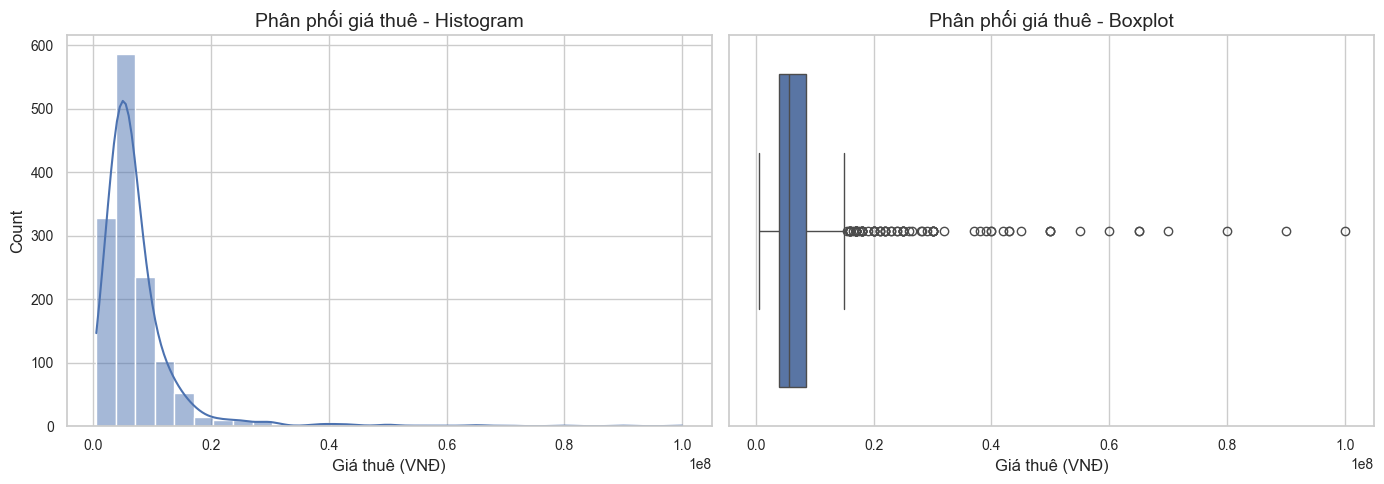

Đã lưu hình: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\outputs\figures\area_distribution.png


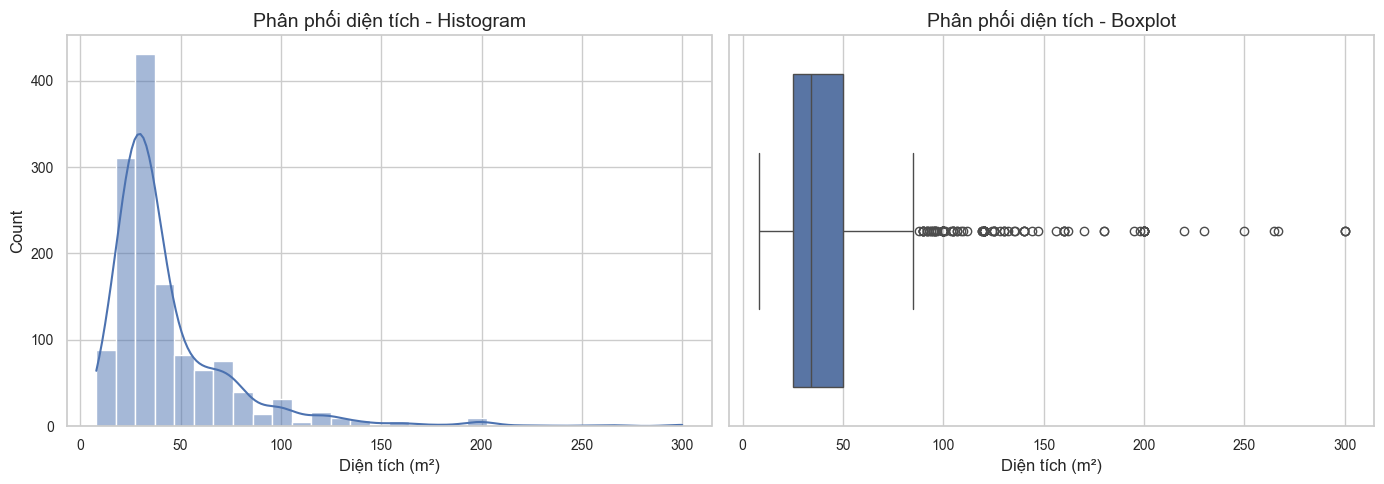

Đã lưu hình: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\outputs\figures\price_per_m2_distribution.png


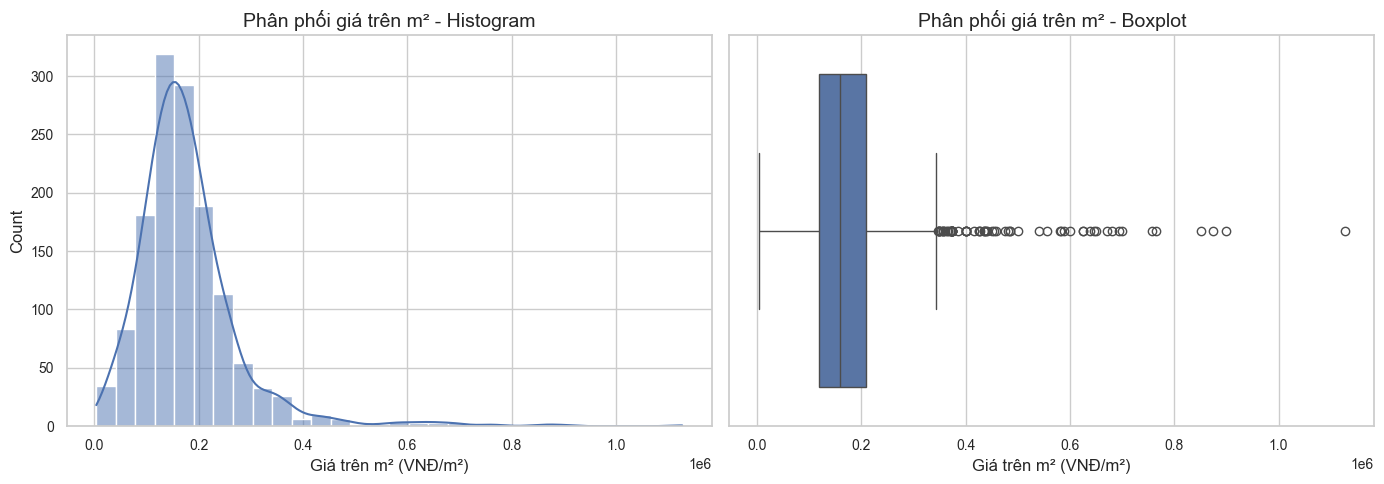

Đã lưu hình: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\outputs\figures\listing_count_by_location.png


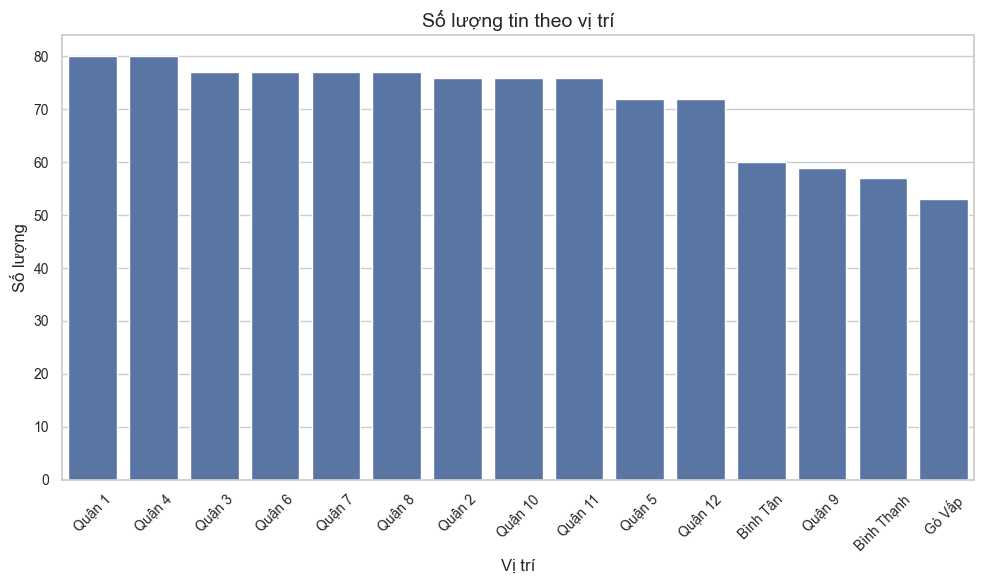

Đã lưu hình: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\outputs\figures\listing_count_by_type.png


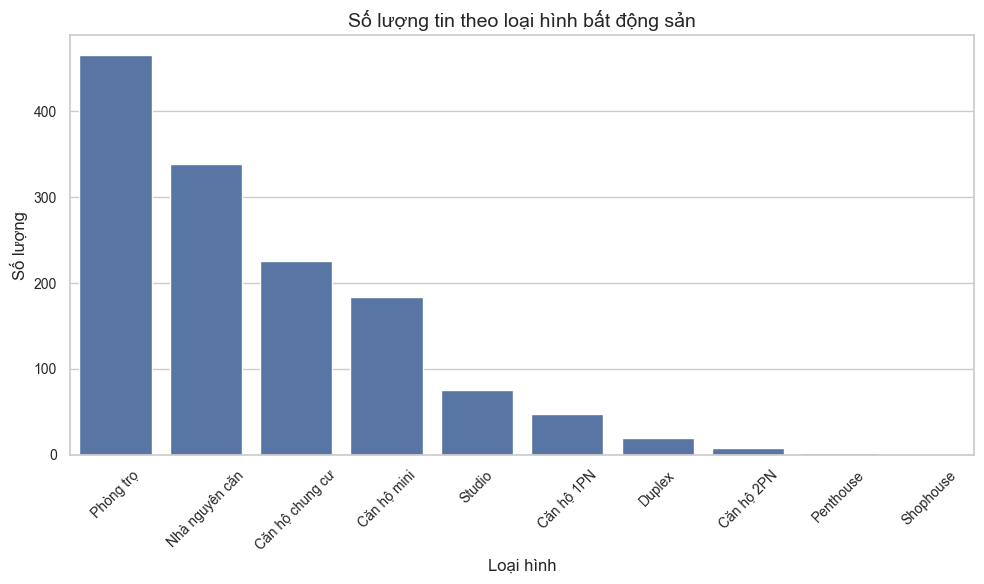

Đã lưu hình: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\outputs\figures\listing_count_by_price_group.png


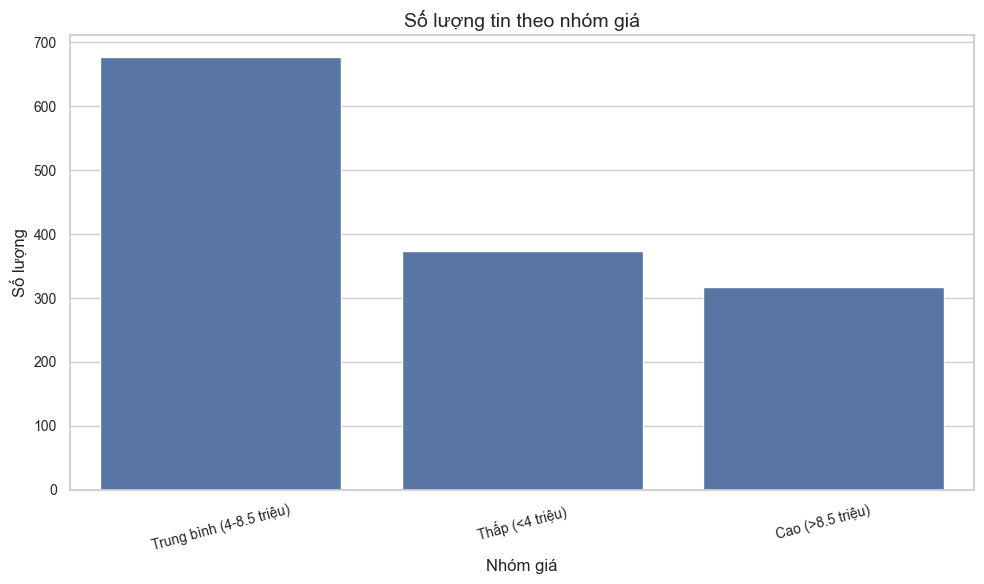

Đã lưu hình: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\outputs\figures\listing_count_by_area_group.png


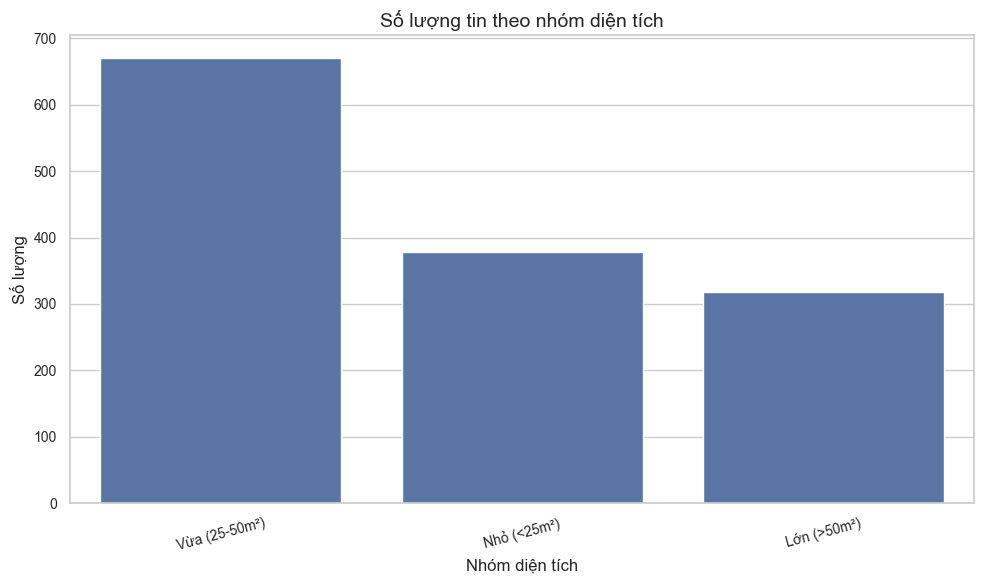

In [9]:
# PHÂN TÍCH ĐƠN BIẾN

print_section("Phân tích đơn biến")

# Thống kê mô tả biến số chính
numeric_summary = summarize_numeric(df_analysis, ["price_vnd", "area_m2", "price_per_m2", "sophong"])
display(numeric_summary)

# 1. Phân phối giá thuê
plot_hist_box(
    df_analysis,
    col="price_vnd",
    title_prefix="Phân phối giá thuê",
    bins=30,
    x_label="Giá thuê (VNĐ)",
    filename_prefix="price_distribution"
)

# 2. Phân phối diện tích
plot_hist_box(
    df_analysis,
    col="area_m2",
    title_prefix="Phân phối diện tích",
    bins=30,
    x_label="Diện tích (m²)",
    filename_prefix="area_distribution"
)

# 3. Phân phối giá trên m²
plot_hist_box(
    df_analysis,
    col="price_per_m2",
    title_prefix="Phân phối giá trên m²",
    bins=30,
    x_label="Giá trên m² (VNĐ/m²)",
    filename_prefix="price_per_m2_distribution"
)

# 4. Số lượng tin theo vị trí
barplot_counts(
    df_analysis["standardized_location"],
    title="Số lượng tin theo vị trí",
    xlabel="Vị trí",
    top_n=15,
    rotate=45,
    filename="listing_count_by_location.png"
)

# 5. Số lượng tin theo loại hình
barplot_counts(
    df_analysis["property_type_clean"],
    title="Số lượng tin theo loại hình bất động sản",
    xlabel="Loại hình",
    rotate=45,
    filename="listing_count_by_type.png"
)

# 6. Số lượng theo nhóm giá
barplot_counts(
    df_analysis["price_group"],
    title="Số lượng tin theo nhóm giá",
    xlabel="Nhóm giá",
    rotate=15,
    filename="listing_count_by_price_group.png"
)

# 7. Số lượng theo nhóm diện tích
barplot_counts(
    df_analysis["area_group"],
    title="Số lượng tin theo nhóm diện tích",
    xlabel="Nhóm diện tích",
    rotate=15,
    filename="listing_count_by_area_group.png"
)

## Nhận xét đơn biến

- Giá thuê có xu hướng lệch phải, cho thấy tồn tại một số tin đăng giá rất cao.
- Diện tích chủ yếu tập trung ở nhóm nhỏ đến trung bình.
- Giá trên mét vuông giúp phản ánh rõ hơn sự khác biệt giữa các loại hình và khu vực.
- Dataset tập trung nhiều ở một số loại hình như phòng trọ, nhà nguyên căn và căn hộ chung cư.

## Phân tích hai biến và đa biến

Đã lưu hình: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\outputs\figures\median_price_by_location.png


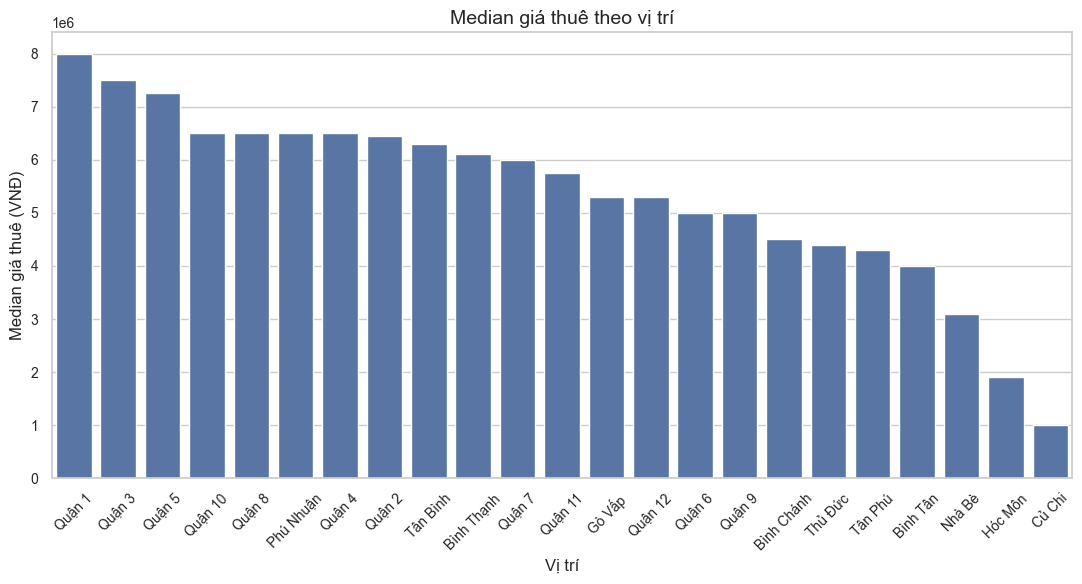

,standardized_location,median,count
9,Quận 1,"8,000,000.00",80
14,Quận 3,"7,500,000.00",77
16,Quận 5,"7,250,000.00",72
10,Quận 10,"6,500,000.00",76
19,Quận 8,"6,500,000.00",77
8,Phú Nhuận,"6,500,000.00",53
15,Quận 4,"6,500,000.00",80
13,Quận 2,"6,450,000.00",76
22,Tân Bình,"6,300,000.00",53
1,Bình Thạnh,"6,100,000.00",57


Đã lưu hình: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\outputs\figures\boxplot_price_by_location.png


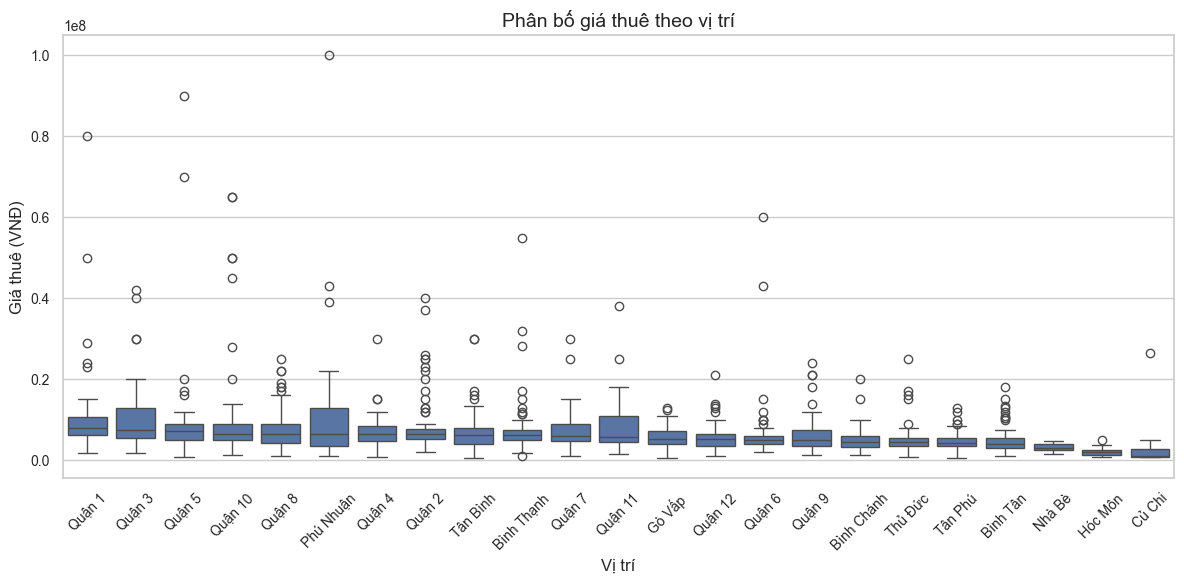

Đã lưu hình: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\outputs\figures\median_price_by_type.png


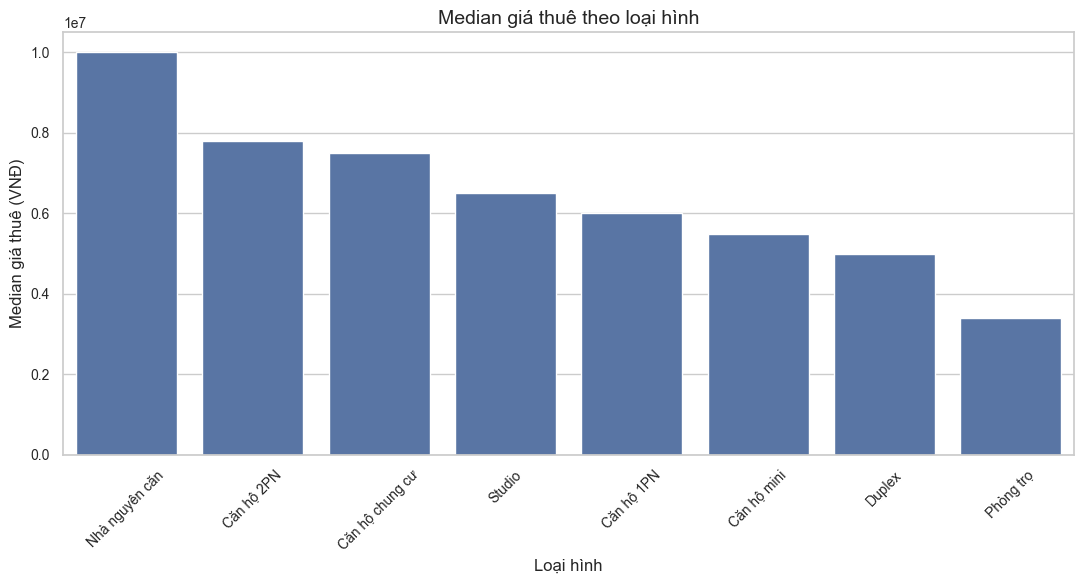

,property_type_clean,median,count
5,Nhà nguyên căn,"10,000,000.00",339
1,Căn hộ 2PN,"7,800,000.00",8
2,Căn hộ chung cư,"7,500,000.00",226
9,Studio,"6,500,000.00",75
0,Căn hộ 1PN,"6,000,000.00",48
3,Căn hộ mini,"5,500,000.00",184
4,Duplex,"5,000,000.00",20
7,Phòng trọ,"3,400,000.00",465


Đã lưu hình: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\outputs\figures\boxplot_price_by_type.png


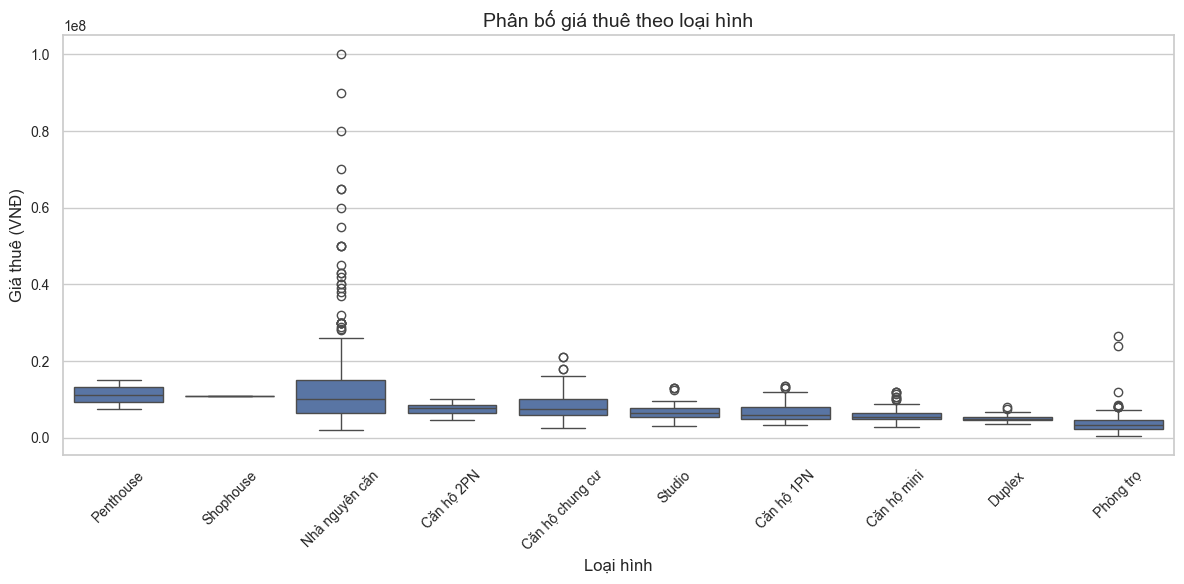

Đã lưu hình: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\outputs\figures\median_area_by_type.png


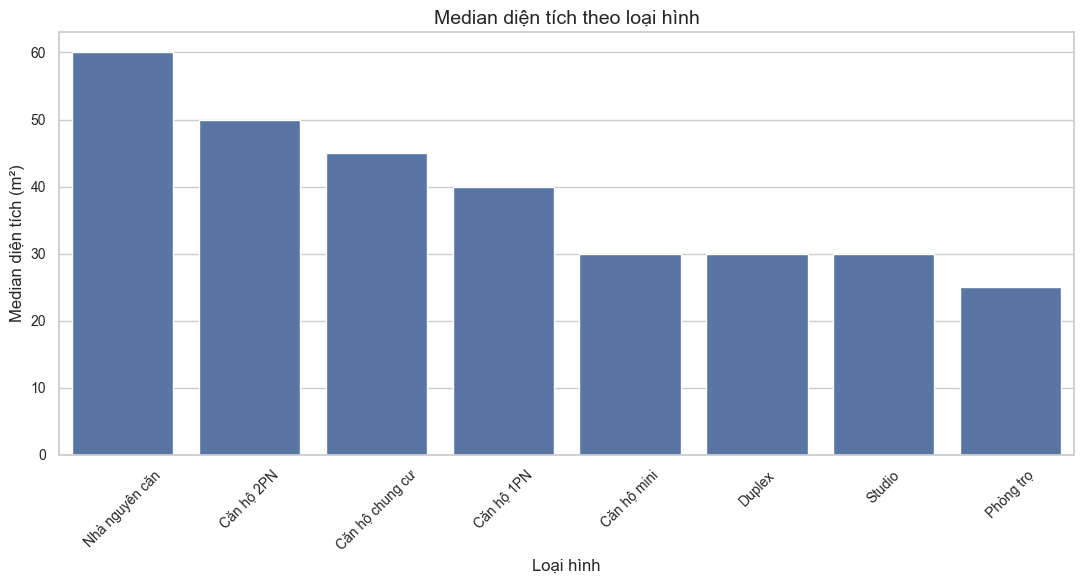

,property_type_clean,median,count
5,Nhà nguyên căn,60.00,339
1,Căn hộ 2PN,50.00,8
2,Căn hộ chung cư,45.00,226
0,Căn hộ 1PN,40.00,48
3,Căn hộ mini,30.00,184
4,Duplex,30.00,20
9,Studio,30.00,75
7,Phòng trọ,25.00,465


Đã lưu hình: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\outputs\figures\median_price_per_m2_by_location.png


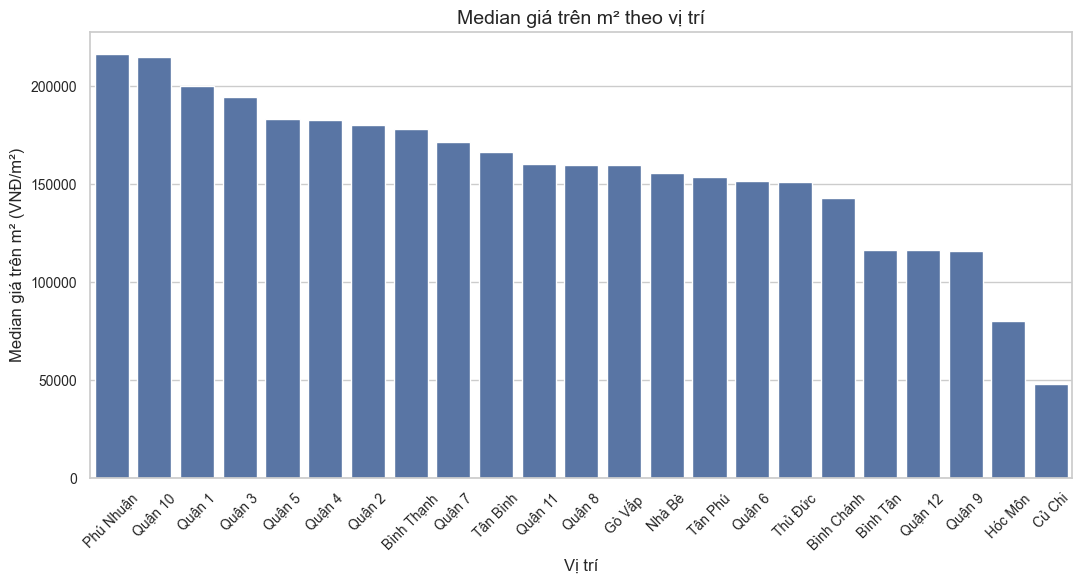

,standardized_location,median,count
8,Phú Nhuận,"216,666.67",53
10,Quận 10,"215,000.00",76
9,Quận 1,"200,000.00",80
14,Quận 3,"194,444.44",77
16,Quận 5,"183,333.33",72
15,Quận 4,"182,575.76",80
13,Quận 2,"180,000.00",76
1,Bình Thạnh,"178,378.38",57
18,Quận 7,"171,428.57",77
22,Tân Bình,"166,666.67",53


Đã lưu hình: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\outputs\figures\median_price_per_m2_by_type.png


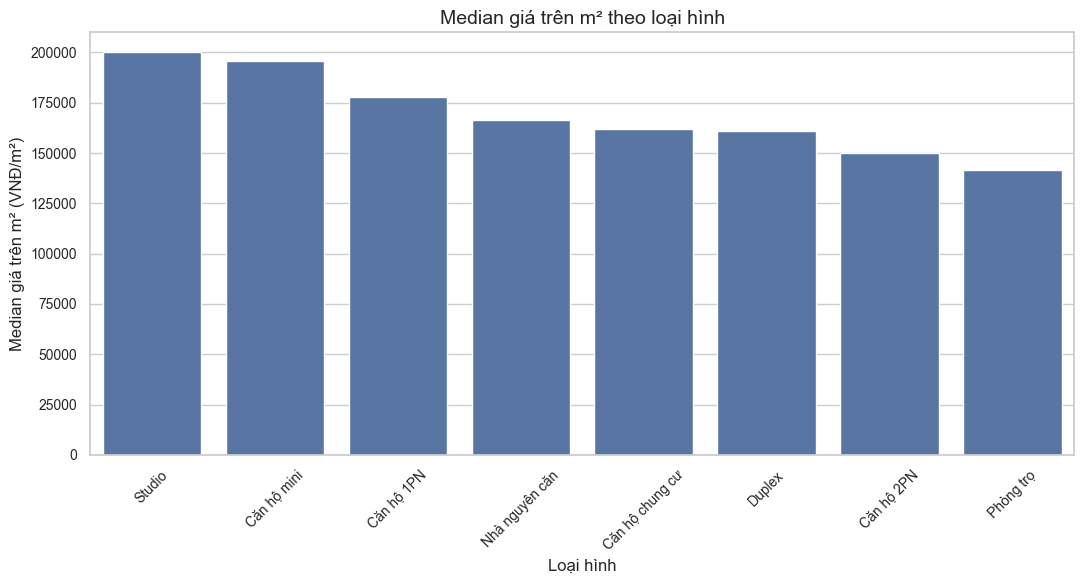

,property_type_clean,median,count
9,Studio,"200,000.00",75
3,Căn hộ mini,"196,000.00",184
0,Căn hộ 1PN,"177,777.78",48
5,Nhà nguyên căn,"166,666.67",339
2,Căn hộ chung cư,"162,192.19",226
4,Duplex,"160,714.29",20
1,Căn hộ 2PN,"150,000.00",8
7,Phòng trọ,"141,666.67",465


Đã lưu hình: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\outputs\figures\area_vs_price_scatter.png


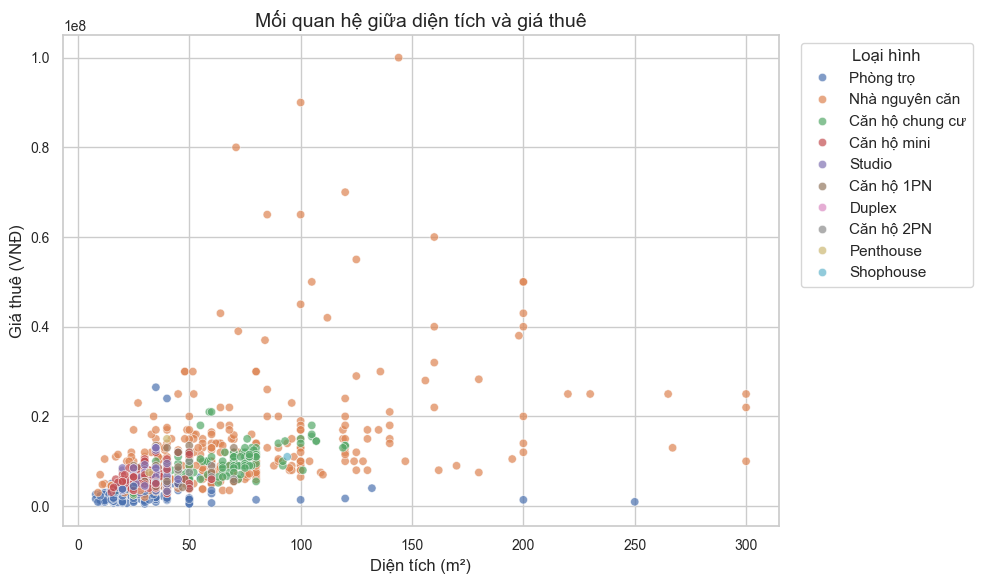

Đã lưu hình: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\outputs\figures\correlation_heatmap.png


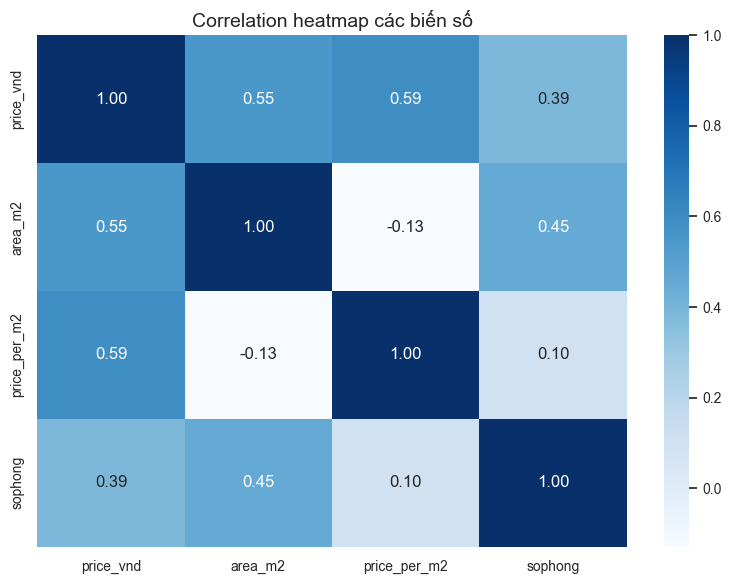

In [10]:
# PHÂN TÍCH ĐƠN BIẾN VÀ ĐA BIẾN

print_section("Phân tích hai biến và đa biến")

# 1. Median giá theo vị trí
median_price_by_location = barplot_median(
    df_analysis,
    category_col="standardized_location",
    value_col="price_vnd",
    title="Median giá thuê theo vị trí",
    xlabel="Vị trí",
    ylabel="Median giá thuê (VNĐ)",
    min_count=10,
    rotate=45,
    filename="median_price_by_location.png"
)
display(median_price_by_location)

# 2. Boxplot giá theo vị trí
boxplot_by_category(
    df_analysis[df_analysis["standardized_location"].isin(median_price_by_location["standardized_location"])],
    category_col="standardized_location",
    value_col="price_vnd",
    title="Phân bố giá thuê theo vị trí",
    xlabel="Vị trí",
    ylabel="Giá thuê (VNĐ)",
    filename="boxplot_price_by_location.png"
)

# 3. Median giá theo loại hình
median_price_by_type = barplot_median(
    df_analysis,
    category_col="property_type_clean",
    value_col="price_vnd",
    title="Median giá thuê theo loại hình",
    xlabel="Loại hình",
    ylabel="Median giá thuê (VNĐ)",
    min_count=5,
    rotate=45,
    filename="median_price_by_type.png"
)
display(median_price_by_type)

# 4. Boxplot giá theo loại hình
boxplot_by_category(
    df_analysis,
    category_col="property_type_clean",
    value_col="price_vnd",
    title="Phân bố giá thuê theo loại hình",
    xlabel="Loại hình",
    ylabel="Giá thuê (VNĐ)",
    filename="boxplot_price_by_type.png"
)

# 5. Median diện tích theo loại hình
median_area_by_type = barplot_median(
    df_analysis,
    category_col="property_type_clean",
    value_col="area_m2",
    title="Median diện tích theo loại hình",
    xlabel="Loại hình",
    ylabel="Median diện tích (m²)",
    min_count=5,
    rotate=45,
    filename="median_area_by_type.png"
)
display(median_area_by_type)

# 6. Giá trên m² theo vị trí
median_ppm2_by_location = barplot_median(
    df_analysis,
    category_col="standardized_location",
    value_col="price_per_m2",
    title="Median giá trên m² theo vị trí",
    xlabel="Vị trí",
    ylabel="Median giá trên m² (VNĐ/m²)",
    min_count=10,
    rotate=45,
    filename="median_price_per_m2_by_location.png"
)
display(median_ppm2_by_location)

# 7. Giá trên m² theo loại hình
median_ppm2_by_type = barplot_median(
    df_analysis,
    category_col="property_type_clean",
    value_col="price_per_m2",
    title="Median giá trên m² theo loại hình",
    xlabel="Loại hình",
    ylabel="Median giá trên m² (VNĐ/m²)",
    min_count=5,
    rotate=45,
    filename="median_price_per_m2_by_type.png"
)
display(median_ppm2_by_type)

# 8. Scatter diện tích vs giá
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=df_analysis,
    x="area_m2",
    y="price_vnd",
    hue="property_type_clean",
    alpha=0.7,
    ax=ax
)
ax.set_title("Mối quan hệ giữa diện tích và giá thuê")
ax.set_xlabel("Diện tích (m²)")
ax.set_ylabel("Giá thuê (VNĐ)")
plt.legend(title="Loại hình", bbox_to_anchor=(1.02, 1), loc="upper left")
save_figure(fig, "area_vs_price_scatter.png")
plt.show()

# 9. Heatmap tương quan
numeric_cols = ["price_vnd", "area_m2", "price_per_m2", "sophong"]
corr = df_analysis[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f", ax=ax)
ax.set_title("Correlation heatmap các biến số")
save_figure(fig, "correlation_heatmap.png")
plt.show()

## Nhận xét theo nhóm

- Vị trí và loại hình bất động sản là hai yếu tố phân tầng giá rõ nhất trong dataset.
- Diện tích có mối liên hệ dương với giá thuê, tuy nhiên không hoàn toàn tuyến tính.
- Khi xét theo giá trên mét vuông, một số loại hình nhỏ gọn nhưng tiện nghi có thể nổi bật hơn nhóm diện tích lớn.

## Khai thác keyword từ tiêu đề

,keyword,count,ratio
3,has_furniture,276,0.20
1,has_balcony,146,0.11
0,has_studio,128,0.09
4,has_new,69,0.05
5,has_window,64,0.05
2,has_mezzanine,20,0.01
6,has_elevator,18,0.01


Đã lưu hình: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\outputs\figures\keyword_frequency.png


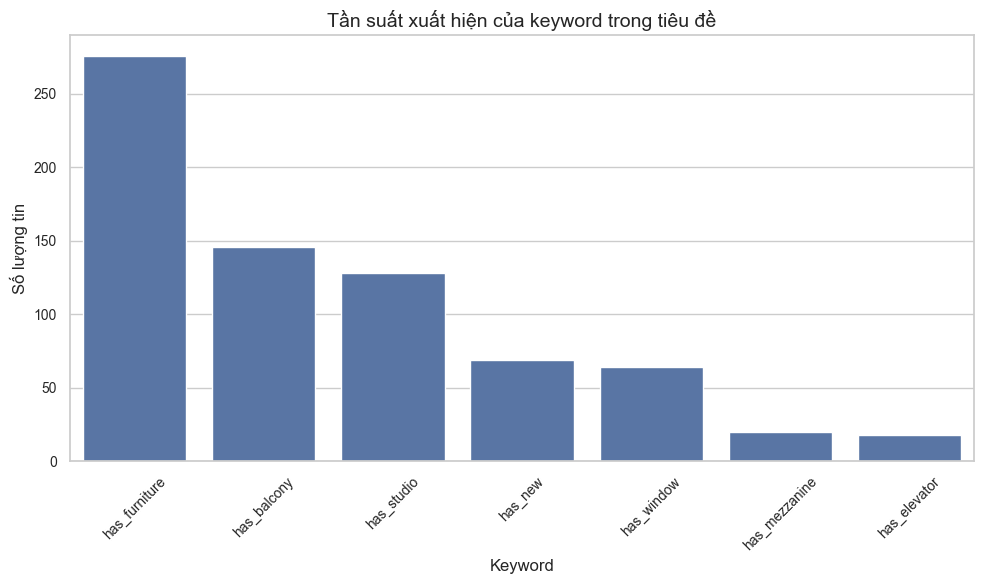

,has_keyword,median_price_vnd,keyword
0,Không,"5,500,000.00",has_studio
1,Có,"6,450,000.00",has_studio
2,Không,"5,600,000.00",has_balcony
3,Có,"6,000,000.00",has_balcony
4,Không,"5,800,000.00",has_mezzanine
5,Có,"4,250,000.00",has_mezzanine
6,Không,"6,000,000.00",has_furniture
7,Có,"5,350,000.00",has_furniture
8,Không,"5,800,000.00",has_new
9,Có,"4,900,000.00",has_new


Đã lưu hình: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\outputs\figures\keyword_price_comparison.png


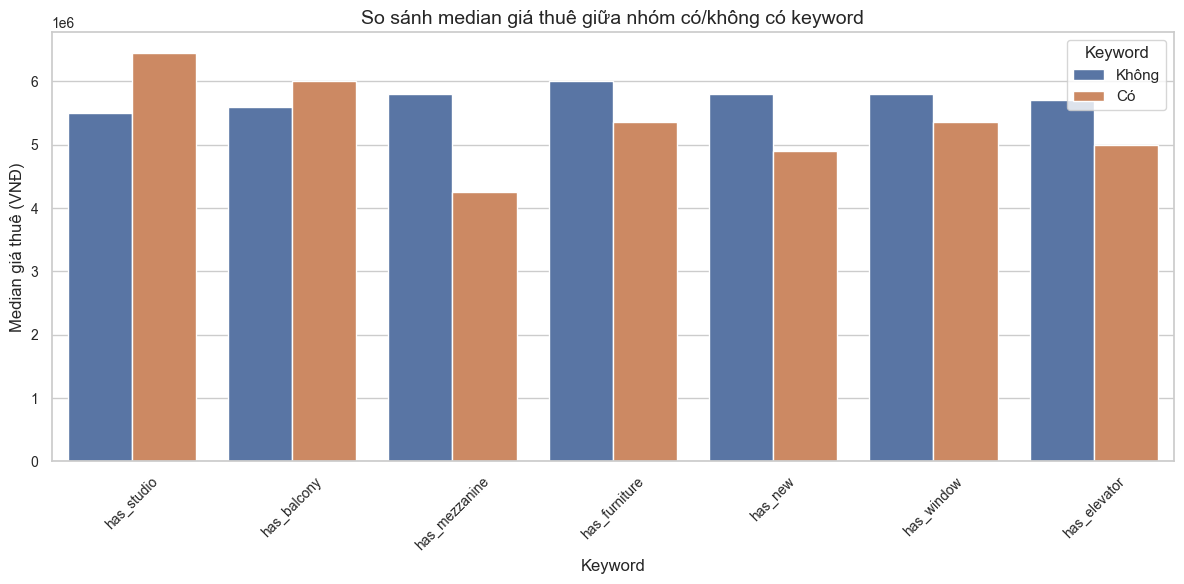

,has_keyword,median_price_per_m2,keyword
0,Không,"157,142.86",has_studio
1,Có,"209,124.42",has_studio
2,Không,"157,166.75",has_balcony
3,Có,"183,333.33",has_balcony
4,Không,"160,357.14",has_mezzanine
5,Có,"163,333.33",has_mezzanine
6,Không,"156,250.00",has_furniture
7,Có,"180,000.00",has_furniture
8,Không,"160,000.00",has_new
9,Có,"177,272.73",has_new


Đã lưu hình: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\outputs\figures\keyword_price_per_m2_comparison.png


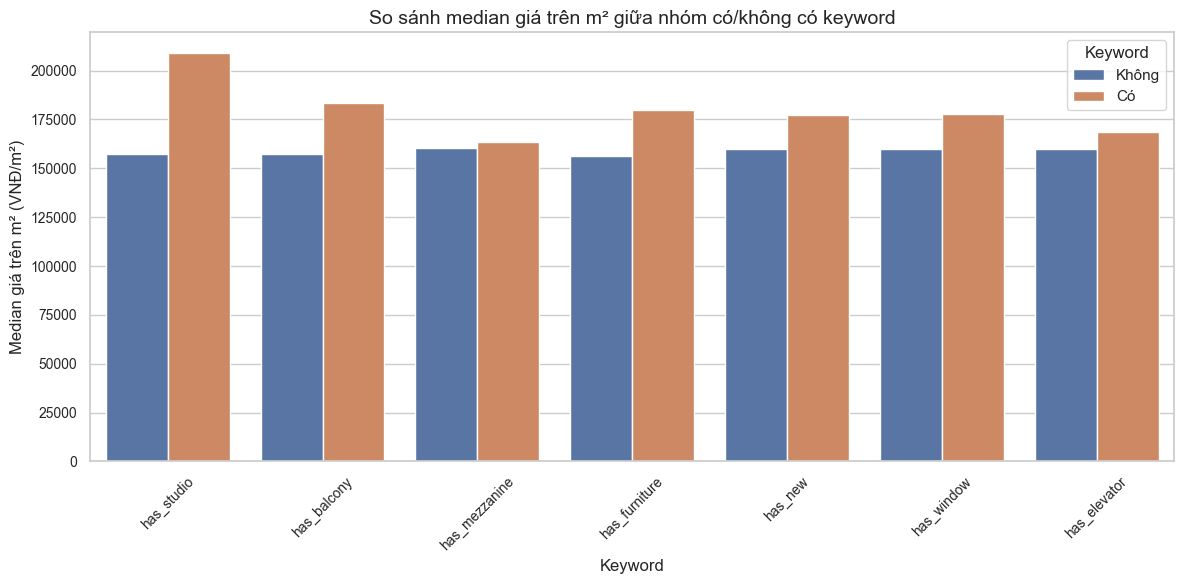

In [11]:
# KHAI THÁC TỪ TIÊU ĐỀ TIN ĐĂNG, KEYWORD

print_section("Khai thác keyword từ tiêu đề")

keyword_cols = list(keyword_patterns.keys())

# Tần suất keyword
keyword_freq = (
    pd.DataFrame({
        "keyword": keyword_cols,
        "count": [df_analysis[col].sum() for col in keyword_cols],
        "ratio": [df_analysis[col].mean() for col in keyword_cols]
    })
    .sort_values("count", ascending=False)
)

display(keyword_freq)

# Bar chart tần suất keyword
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=keyword_freq, x="keyword", y="count", ax=ax)
ax.set_title("Tần suất xuất hiện của keyword trong tiêu đề")
ax.set_xlabel("Keyword")
ax.set_ylabel("Số lượng tin")
plt.xticks(rotation=45)
save_figure(fig, "keyword_frequency.png")
plt.show()

# So sánh median giá giữa có keyword và không có keyword
keyword_price_compare = []
for col in keyword_cols:
    temp = (
        df_analysis.groupby(col)["price_vnd"]
        .median()
        .rename("median_price_vnd")
        .reset_index()
    )
    temp["keyword"] = col
    temp[col] = temp[col].map({True: "Có", False: "Không"})
    temp = temp.rename(columns={col: "has_keyword"})
    keyword_price_compare.append(temp)

keyword_price_compare = pd.concat(keyword_price_compare, ignore_index=True)
display(keyword_price_compare)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=keyword_price_compare,
    x="keyword",
    y="median_price_vnd",
    hue="has_keyword",
    ax=ax
)
ax.set_title("So sánh median giá thuê giữa nhóm có/không có keyword")
ax.set_xlabel("Keyword")
ax.set_ylabel("Median giá thuê (VNĐ)")
plt.xticks(rotation=45)
plt.legend(title="Keyword")
save_figure(fig, "keyword_price_comparison.png")
plt.show()

# So sánh median giá trên m² giữa có keyword và không có keyword
keyword_ppm2_compare = []
for col in keyword_cols:
    temp = (
        df_analysis.groupby(col)["price_per_m2"]
        .median()
        .rename("median_price_per_m2")
        .reset_index()
    )
    temp["keyword"] = col
    temp[col] = temp[col].map({True: "Có", False: "Không"})
    temp = temp.rename(columns={col: "has_keyword"})
    keyword_ppm2_compare.append(temp)

keyword_ppm2_compare = pd.concat(keyword_ppm2_compare, ignore_index=True)
display(keyword_ppm2_compare)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=keyword_ppm2_compare,
    x="keyword",
    y="median_price_per_m2",
    hue="has_keyword",
    ax=ax
)
ax.set_title("So sánh median giá trên m² giữa nhóm có/không có keyword")
ax.set_xlabel("Keyword")
ax.set_ylabel("Median giá trên m² (VNĐ/m²)")
plt.xticks(rotation=45)
plt.legend(title="Keyword")
save_figure(fig, "keyword_price_per_m2_comparison.png")
plt.show()

## Phân khúc thị trường

,market_segment,listing_count,median_price_vnd,median_area_m2,median_price_per_m2,top_property_type,top_location
2,Tiện nghi vừa,800,"5,100,000.00",30.00,"166,666.67",Phòng trọ,Quận 6
0,Không gian lớn / gia đình,410,"11,000,000.00",70.00,"150,766.19",Nhà nguyên căn,Quận 1
1,Tiết kiệm,158,"2,700,000.00",18.00,"155,625.00",Phòng trọ,Củ Chi


Đã lưu hình: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\outputs\figures\market_segment_count.png


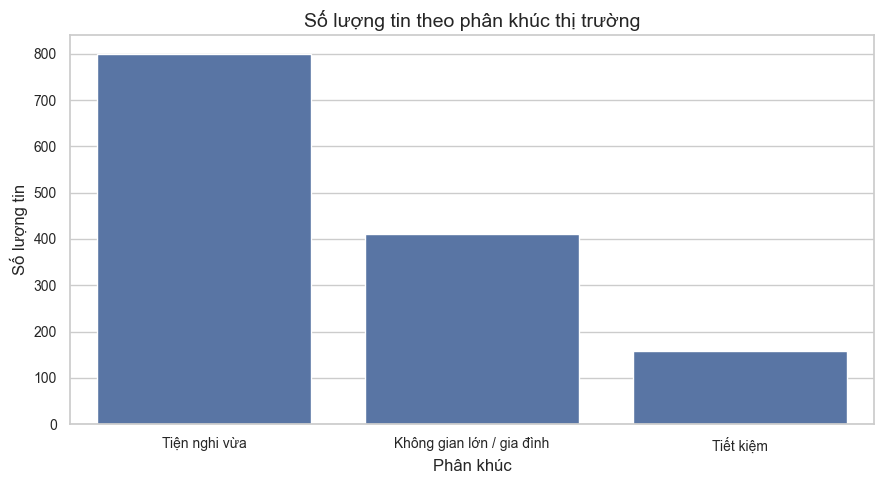

In [12]:
# PHÂN KHÚC THỊ TRƯỜNG

print_section("Phân khúc thị trường")

def assign_market_segment(row):
    if row["price_vnd"] < 4_000_000 and row["area_m2"] < 25:
        return "Tiết kiệm"
    elif row["price_vnd"] <= 8_500_000 and row["area_m2"] <= 50:
        return "Tiện nghi vừa"
    else:
        return "Không gian lớn / gia đình"

df_analysis["market_segment"] = df_analysis.apply(assign_market_segment, axis=1)

segment_summary = (
    df_analysis.groupby("market_segment")
    .agg(
        listing_count=("market_segment", "size"),
        median_price_vnd=("price_vnd", "median"),
        median_area_m2=("area_m2", "median"),
        median_price_per_m2=("price_per_m2", "median"),
        top_property_type=("property_type_clean", lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
        top_location=("standardized_location", lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    )
    .reset_index()
    .sort_values("listing_count", ascending=False)
)

display(segment_summary)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=segment_summary, x="market_segment", y="listing_count", ax=ax)
ax.set_title("Số lượng tin theo phân khúc thị trường")
ax.set_xlabel("Phân khúc")
ax.set_ylabel("Số lượng tin")
save_figure(fig, "market_segment_count.png")
plt.show()

In [13]:
# INSIGHT CHÍNH 

print_section("Tổng hợp insight chính")

top_location_row = median_price_by_location.iloc[0] if not median_price_by_location.empty else None
lowest_type_row = median_price_by_type.sort_values("median", ascending=True).iloc[0] if not median_price_by_type.empty else None
highest_type_row = median_price_by_type.iloc[0] if not median_price_by_type.empty else None
top_keyword_row = keyword_freq.iloc[0] if not keyword_freq.empty else None

insights = []

insights.append(
    f"Dataset sau làm sạch và lọc ngoại lệ phục vụ phân tích còn {len(df_analysis):,} tin đăng."
)

insights.append(
    f"Median giá thuê là {df_analysis['price_vnd'].median():,.0f} VNĐ; phân phối giá có xu hướng lệch phải."
)

insights.append(
    f"Median diện tích là {df_analysis['area_m2'].median():,.1f} m²; phần lớn tin đăng tập trung ở nhóm diện tích nhỏ và vừa."
)

if top_location_row is not None:
    insights.append(
        f"Vị trí có median giá cao nổi bật là {top_location_row['standardized_location']} với mức khoảng {top_location_row['median']:,.0f} VNĐ."
    )

if highest_type_row is not None and lowest_type_row is not None:
    insights.append(
        f"Loại hình có median giá cao nhất là {highest_type_row['property_type_clean']} (~{highest_type_row['median']:,.0f} VNĐ), "
        f"trong khi thấp nhất là {lowest_type_row['property_type_clean']} (~{lowest_type_row['median']:,.0f} VNĐ)."
    )

corr_area_price = df_analysis[["area_m2", "price_vnd"]].corr().iloc[0, 1]
insights.append(
    f"Tương quan giữa diện tích và giá thuê là {corr_area_price:.2f}, cho thấy mối liên hệ dương nhưng không hoàn toàn tuyến tính."
)

if top_keyword_row is not None:
    insights.append(
        f"Keyword xuất hiện nhiều nhất trong tiêu đề là '{top_keyword_row['keyword']}' với {int(top_keyword_row['count'])} tin."
    )

for idx, text in enumerate(insights, start=1):
    print(f"{idx}. {text}")

## Tổng hợp insight chính

1. Dataset sau làm sạch và lọc ngoại lệ phục vụ phân tích còn 1,368 tin đăng.
2. Median giá thuê là 5,700,000 VNĐ; phân phối giá có xu hướng lệch phải.
3. Median diện tích là 34.0 m²; phần lớn tin đăng tập trung ở nhóm diện tích nhỏ và vừa.
4. Vị trí có median giá cao nổi bật là Quận 1 với mức khoảng 8,000,000 VNĐ.
5. Loại hình có median giá cao nhất là Nhà nguyên căn (~10,000,000 VNĐ), trong khi thấp nhất là Phòng trọ (~3,400,000 VNĐ).
6. Tương quan giữa diện tích và giá thuê là 0.55, cho thấy mối liên hệ dương nhưng không hoàn toàn tuyến tính.
7. Keyword xuất hiện nhiều nhất trong tiêu đề là 'has_furniture' với 276 tin.


In [14]:
# HẠN CHẾ 

print_section("Hạn chế của dữ liệu")

limitations = [
    "Dữ liệu là dữ liệu tin đăng, không phải giá giao dịch thực tế.",
    "Dataset không chứa đầy đủ các biến chi tiết như tọa độ, phí dịch vụ, số toilet, tình trạng nội thất chuẩn hóa.",
    "Một số đặc điểm sản phẩm được suy ra từ tiêu đề nên chỉ mang tính xấp xỉ.",
    "Kết quả phân tích mang tính mô tả trên sample hiện có, không đại diện tuyệt đối cho toàn thị trường.",
]

for item in limitations:
    print("-", item)

## Hạn chế của dữ liệu

- Dữ liệu là dữ liệu tin đăng, không phải giá giao dịch thực tế.
- Dataset không chứa đầy đủ các biến chi tiết như tọa độ, phí dịch vụ, số toilet, tình trạng nội thất chuẩn hóa.
- Một số đặc điểm sản phẩm được suy ra từ tiêu đề nên chỉ mang tính xấp xỉ.
- Kết quả phân tích mang tính mô tả trên sample hiện có, không đại diện tuyệt đối cho toàn thị trường.


In [15]:
# BÁO CÁO 

print_section("Xuất báo cáo tổng hợp")

summary_xlsx_path = REPORT_DIR / "summary_statistics.xlsx"
summary_md_path = REPORT_DIR / "analysis_summary.md"

# Tạo một số bảng summary
location_summary = (
    df_analysis.groupby("standardized_location")
    .agg(
        listing_count=("standardized_location", "size"),
        median_price_vnd=("price_vnd", "median"),
        median_area_m2=("area_m2", "median"),
        median_price_per_m2=("price_per_m2", "median")
    )
    .sort_values("median_price_vnd", ascending=False)
)

type_summary = (
    df_analysis.groupby("property_type_clean")
    .agg(
        listing_count=("property_type_clean", "size"),
        median_price_vnd=("price_vnd", "median"),
        median_area_m2=("area_m2", "median"),
        median_price_per_m2=("price_per_m2", "median")
    )
    .sort_values("median_price_vnd", ascending=False)
)

with pd.ExcelWriter(summary_xlsx_path, engine="openpyxl") as writer:
    numeric_summary.to_excel(writer, sheet_name="numeric_summary")
    missing_df.to_excel(writer, sheet_name="missing_values")
    location_summary.to_excel(writer, sheet_name="location_summary")
    type_summary.to_excel(writer, sheet_name="type_summary")
    keyword_freq.to_excel(writer, sheet_name="keyword_frequency", index=False)
    segment_summary.to_excel(writer, sheet_name="market_segment", index=False)

print(f"Đã lưu summary statistics: {summary_xlsx_path}")

# Tạo file markdown tổng hợp
summary_md_lines = []
summary_md_lines.append("# Tổng hợp kết quả phân tích dataset PhongTro.xlsx\n")
summary_md_lines.append("## 1. Phạm vi\n")
summary_md_lines.append("- Chỉ sử dụng dataset PhongTro.xlsx\n")
summary_md_lines.append("- Không sử dụng dữ liệu external\n")

summary_md_lines.append("\n## 2. Tổng quan dữ liệu\n")
summary_md_lines.append(f"- Số dòng raw: {len(df_raw):,}\n")
summary_md_lines.append(f"- Số dòng sau loại trùng: {len(df_clean):,}\n")
summary_md_lines.append(f"- Số dòng dùng cho phân tích: {len(df_analysis):,}\n")
summary_md_lines.append(f"- Median giá thuê: {df_analysis['price_vnd'].median():,.0f} VNĐ\n")
summary_md_lines.append(f"- Median diện tích: {df_analysis['area_m2'].median():,.1f} m²\n")
summary_md_lines.append(f"- Median giá trên m²: {df_analysis['price_per_m2'].median():,.0f} VNĐ/m²\n")

summary_md_lines.append("\n## 3. Insight chính\n")
for ins in insights:
    summary_md_lines.append(f"- {ins}\n")

summary_md_lines.append("\n## 4. Hạn chế\n")
for item in limitations:
    summary_md_lines.append(f"- {item}\n")

with open(summary_md_path, "w", encoding="utf-8") as f:
    f.writelines(summary_md_lines)

print(f"Đã lưu markdown summary: {summary_md_path}")

## Xuất báo cáo tổng hợp

Đã lưu summary statistics: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\outputs\reports\summary_statistics.xlsx
Đã lưu markdown summary: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\outputs\reports\analysis_summary.md


# Phân tích Insight Nâng cao (Bổ sung)
### Biểu đồ Heatmap dưới đây cho thấy sự phân bổ giá trung bình kết hợp cả 2 chiều: Phân khúc (Loại hình) và Vị trí (Quận/Huyện). Nó giúp ta nhanh chóng tìm ra các 'vùng trũng' về giá hoặc những khu vực tập trung phân khúc cao cấp.

## Insight Nâng cao: Heatmap Giá Trung Bình theo Loại hình và Vị trí

Đã lưu hình: D:\DOHOANGPHUC\UTH\TriTueNhanTaovaUngDung\Project2\TR-TU-NH-N-T-O-NG-D-NG-\Analysis\outputs\figures\insight_heatmap_gia_vitri_loai_hinh


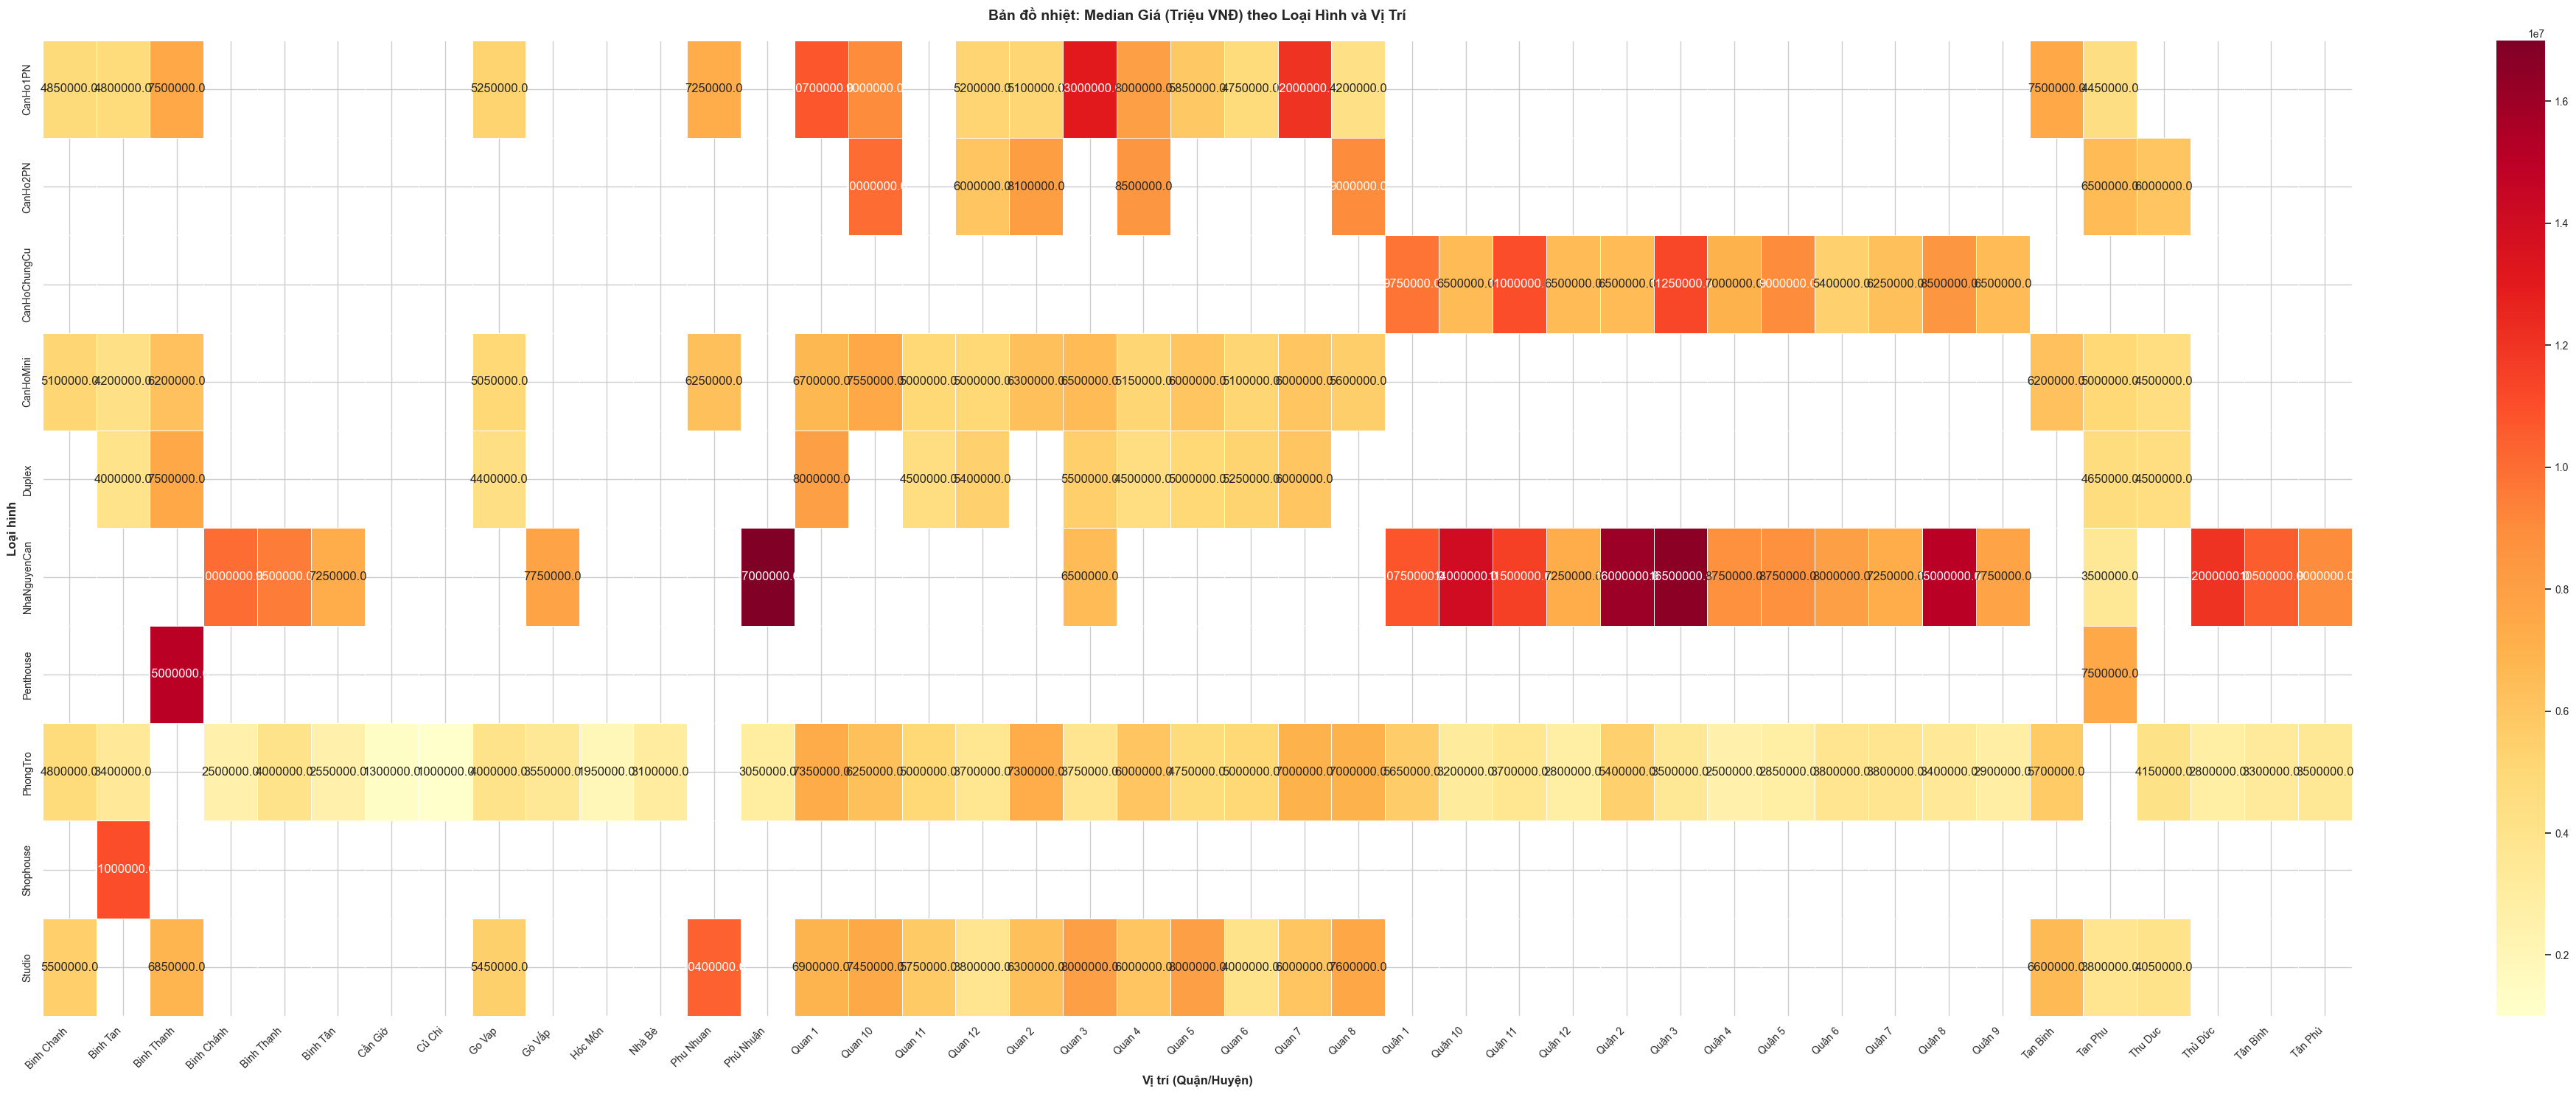

In [21]:
# BỔ SUNG: INSIGHT HEATMAP MẬT ĐỘ GIÁ THEO LOẠI HÌNH VÀ VỊ TRÍ
print_section("Insight Nâng cao: Heatmap Giá Trung Bình theo Loại hình và Vị trí")

try:
    pivot_price = df_clean.pivot_table(index='phanloai', columns='vitri', values='giavnd', aggfunc='median')
    plt.figure(figsize=(40, 15))
    sns.heatmap(pivot_price, annot=True, cmap='YlOrRd', fmt='.1f', linewidths=.5)
    plt.title('Bản đồ nhiệt: Median Giá (Triệu VNĐ) theo Loại Hình và Vị Trí', pad=20, fontsize=14, fontweight='bold')
    plt.ylabel('Loại hình', fontweight='bold')
    plt.xlabel('Vị trí (Quận/Huyện)', fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    save_figure(plt.gcf(), 'insight_heatmap_gia_vitri_loai_hinh')
    plt.show()
except Exception as e:
    print('Lỗi khi vẽ Heatmap:', e)